# ELEC3612 – Assignment 1: Machine Learning Model Implementation and Reporting

**Dataset:** Diabetes Prediction Dataset  
**Models:** Supervised (SVM, Logistic Regression, Decision Tree, Random Forest), Unsupervised (K-Means), Ensemble (Bagging, Boosting, Voting, Stacking)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from google.colab import drive

warnings.filterwarnings('ignore')

# Mount Google Drive
drive.mount('/content/drive')

df_path = '/content/drive/MyDrive/ELEC3612/diabetes_prediction_dataset.csv'
if not os.path.exists(df_path):
    raise FileNotFoundError(f"File not found: {df_path}")

# Load first 10000 rows
df_raw = pd.read_csv(df_path, nrows=10000)
print(f"Loaded {len(df_raw)} rows, {df_raw.shape[1]} columns")
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nFirst 5 rows:")
display(df_raw.head())

Mounted at /content/drive
Loaded 10000 rows, 9 columns

Column dtypes:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

First 5 rows:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## 2. Exploratory Data Analysis (EDA)

=== Dataset Shape ===
(10000, 9)

=== Missing Values ===
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

=== Class Distribution (Diabetes) ===
diabetes
0    9141
1     859
Name: count, dtype: int64
diabetes
0    0.914
1    0.086
Name: proportion, dtype: float64

=== Descriptive Statistics ===


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,41.991556,0.075300,0.037400,27.331413,5.520650,137.852100,0.08590
std,22.540364,0.263888,0.189749,6.650023,1.082118,41.228493,0.28023
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.00000
25%,24.000000,0.000000,0.000000,23.710000,4.800000,100.000000,0.00000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.00000
75%,59.000000,0.000000,0.000000,29.600000,6.200000,159.000000,0.00000
max,80.000000,1.000000,1.000000,88.720000,9.000000,300.000000,1.00000


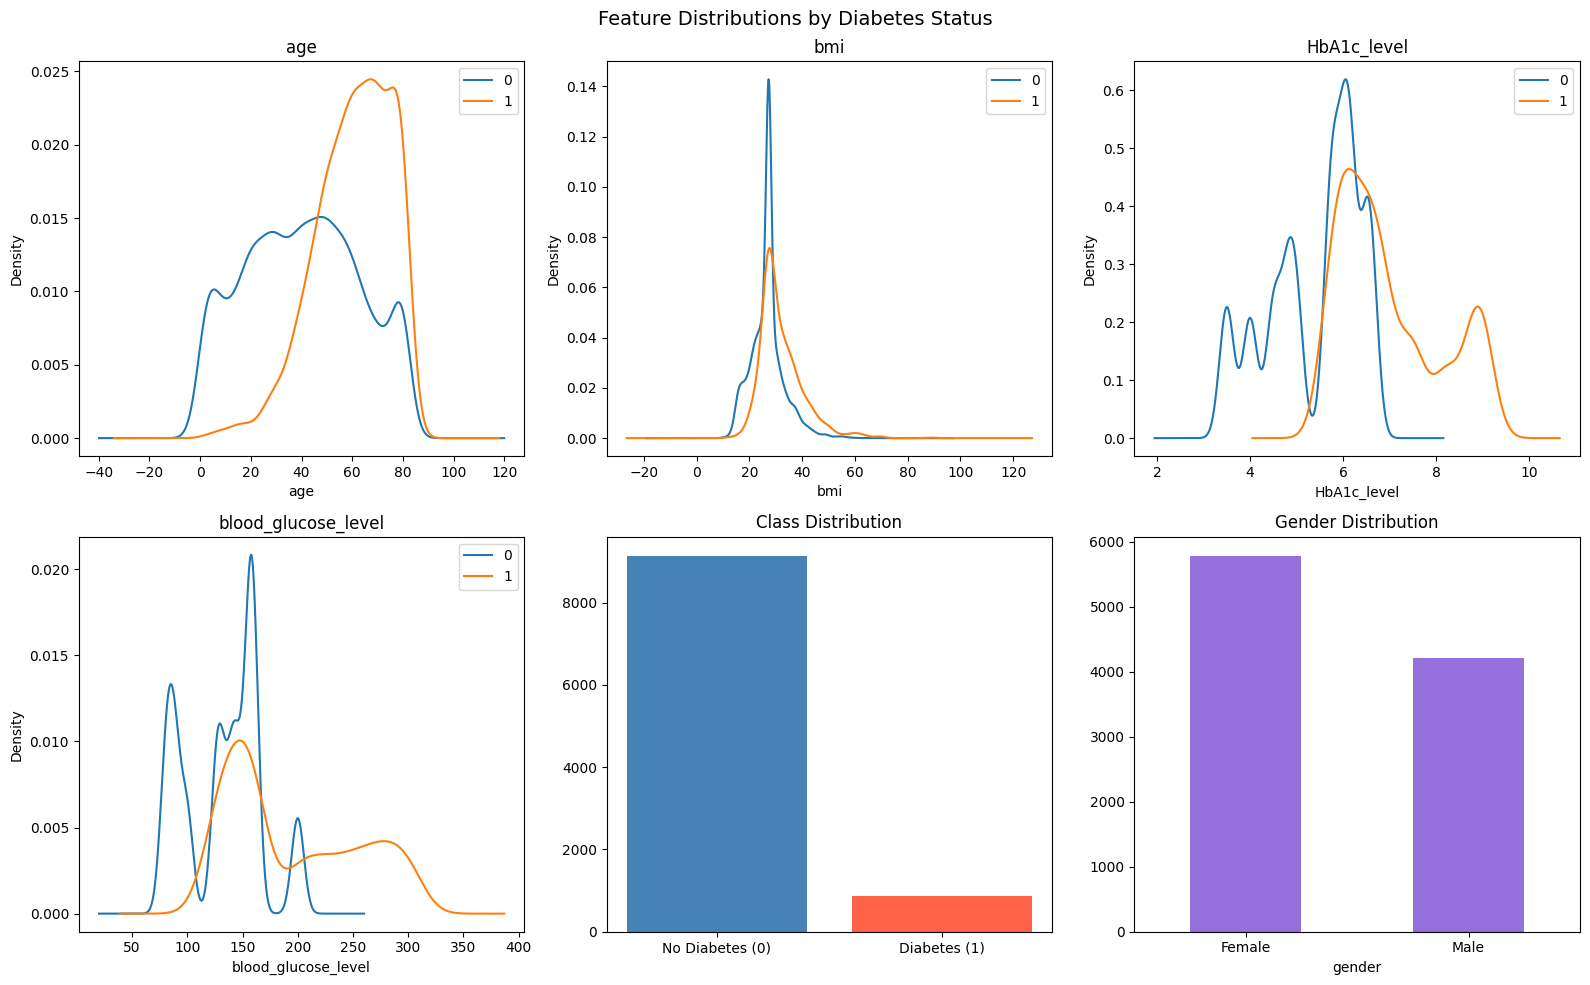

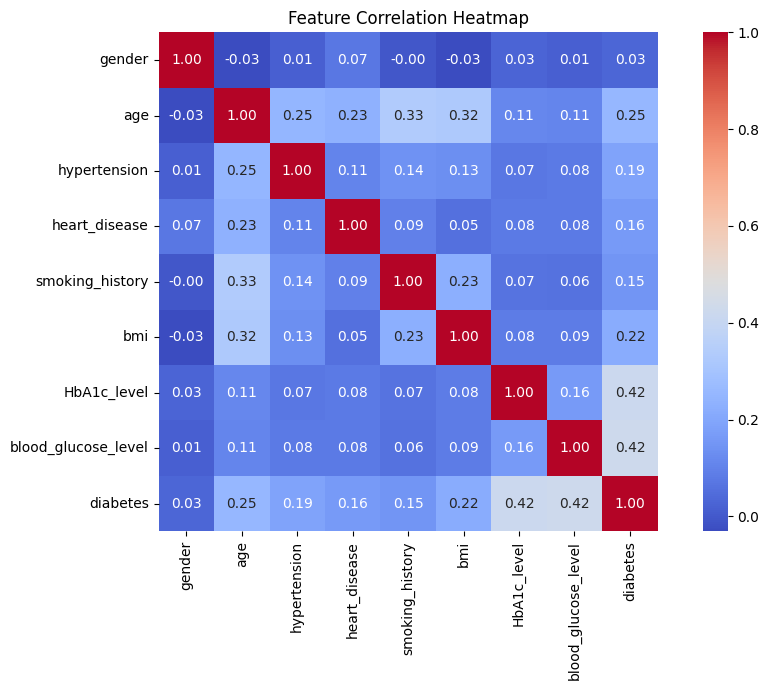

In [2]:
print("=== Dataset Shape ===")
print(df_raw.shape)

print("\n=== Missing Values ===")
print(df_raw.isnull().sum())

print("\n=== Class Distribution (Diabetes) ===")
print(df_raw['diabetes'].value_counts())
print(df_raw['diabetes'].value_counts(normalize=True).round(3))

print("\n=== Descriptive Statistics ===")
display(df_raw.describe())

# --- Visualisations ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions by Diabetes Status', fontsize=14)

numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    df_raw.groupby('diabetes')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
    ax.set_xlabel(col)

# Class distribution bar
axes[1][1].bar(['No Diabetes (0)', 'Diabetes (1)'],
               df_raw['diabetes'].value_counts().values,
               color=['steelblue', 'tomato'])
axes[1][1].set_title('Class Distribution')

# Gender distribution
df_raw['gender'].value_counts().plot(kind='bar', ax=axes[1][2], color='mediumpurple')
axes[1][2].set_title('Gender Distribution')
axes[1][2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Correlation heatmap (numeric only)
df_numeric_eda = df_raw.copy()
df_numeric_eda['gender'] = df_numeric_eda['gender'].replace({'Female': 0, 'Male': 1, 'Other': 2})
df_numeric_eda['gender'] = pd.to_numeric(df_numeric_eda['gender'], errors='coerce')
target_means_eda = df_numeric_eda.groupby('smoking_history')['diabetes'].mean()
df_numeric_eda['smoking_history'] = df_numeric_eda['smoking_history'].map(target_means_eda)
df_numeric_eda.dropna(inplace=True)

plt.figure(figsize=(10, 7))
sns.heatmap(df_numeric_eda.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [3]:
def preprocess(df_input):
    """Full preprocessing pipeline: encode gender, target-encode smoking_history."""
    df = df_input.copy()
    df['gender'] = df['gender'].replace({'Female': 0, 'Male': 1, 'Other': 2})
    df['gender'] = pd.to_numeric(df['gender'], errors='coerce')
    df.dropna(subset=['gender'], inplace=True)
    target_means = df.groupby('smoking_history')['diabetes'].mean()
    df['smoking_history'] = df['smoking_history'].map(target_means)
    df.dropna(inplace=True)
    return df

df = preprocess(df_raw)
X = df.drop('diabetes', axis=1)
y = df['diabetes']
print(f"Preprocessed dataset: {df.shape}")
print(f"Features: {list(X.columns)}")
print(f"\nClass distribution:\n{y.value_counts()}")

Preprocessed dataset: (10000, 9)
Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Class distribution:
diabetes
0    9141
1     859
Name: count, dtype: int64


## 4. Supervised Models

### 4.1 SVM – Systematic Experiments

=== SVM: Effect of Train-Test Split Ratio ===
  SVM split 60/40: Acc=0.9627  F1=0.7256
  SVM split 70/30: Acc=0.9650  F1=0.7494
  SVM split 80/20: Acc=0.9635  F1=0.7384

=== SVM: Effect of Random Seed ===
  SVM seed=0: Acc=0.9620  F1=0.7305
  SVM seed=42: Acc=0.9635  F1=0.7384
  SVM seed=123: Acc=0.9640  F1=0.7410

=== SVM: Stratified vs Non-Stratified Split ===
  SVM Stratified: Acc=0.9635  Recall=0.5988  F1=0.7384
  SVM Non-Stratified: Acc=0.9655  Recall=0.6145  F1=0.7473

=== SVM: Effect of K-Fold CV ===
  k=3: mean F1=0.7275  std=0.0094
  k=5: mean F1=0.7332  std=0.0212
  k=10: mean F1=0.7373  std=0.0249

=== SVM: Without vs With Hyperparameter Tuning ===
  SVM (no tuning): Acc=0.9635  F1=0.7384
  SVM (tuned): Acc=0.9665  F1=0.7698
  Best params: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


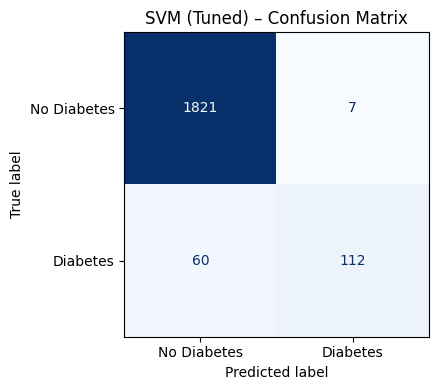


=== SVM Results Summary ===


,Model,Accuracy,Precision,Recall,F1
0,SVM split 60/40,0.9628,0.9899,0.5727,0.7256
1,SVM split 70/30,0.9650,0.9752,0.6085,0.7494
2,SVM split 80/20,0.9635,0.9626,0.5988,0.7384
3,SVM seed=0,0.9620,0.9364,0.5988,0.7305
4,SVM seed=42,0.9635,0.9626,0.5988,0.7384
5,SVM seed=123,0.9640,0.9717,0.5988,0.7410
6,SVM Stratified,0.9635,0.9626,0.5988,0.7384
7,SVM Non-Stratified,0.9655,0.9533,0.6145,0.7473
8,SVM (no tuning),0.9635,0.9626,0.5988,0.7384
9,SVM (tuned),0.9665,0.9412,0.6512,0.7698


In [4]:
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# --- Helper: compute all metrics ---
def get_metrics(y_true, y_pred, model_name=''):
    return {
        'Model': model_name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0)
    }

svm_results = []

# ---- 4.1a  Different train-test split ratios (seed=42) ----
print("=== SVM: Effect of Train-Test Split Ratio ===")
split_ratios = [0.40, 0.30, 0.20]   # 60/40, 70/30, 80/20
for test_size in split_ratios:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
    pipe.fit(X_tr, y_tr)
    m = get_metrics(y_te, pipe.predict(X_te), f'SVM split {int((1-test_size)*100)}/{int(test_size*100)}')
    svm_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- 4.1b  Different random seeds (80/20 split) ----
print("\n=== SVM: Effect of Random Seed ===")
for seed in [0, 42, 123]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=seed, stratify=y)
    pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=seed))
    pipe.fit(X_tr, y_tr)
    m = get_metrics(y_te, pipe.predict(X_te), f'SVM seed={seed}')
    svm_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- 4.1c  Stratified vs Non-Stratified (80/20) ----
print("\n=== SVM: Stratified vs Non-Stratified Split ===")
for strat, label in [(y, 'Stratified'), (None, 'Non-Stratified')]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=strat)
    pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
    pipe.fit(X_tr, y_tr)
    m = get_metrics(y_te, pipe.predict(X_te), f'SVM {label}')
    svm_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  Recall={m['Recall']:.4f}  F1={m['F1']:.4f}")

# ---- 4.1d  K-Fold CV (k = 3, 5, 10) ----
print("\n=== SVM: Effect of K-Fold CV ===")
pipe_cv = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
for k in [3, 5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(pipe_cv, X, y, cv=kf, scoring='f1')
    print(f"  k={k}: mean F1={scores.mean():.4f}  std={scores.std():.4f}")

# ---- 4.1e  Hyperparameter Tuning ----
print("\n=== SVM: Without vs With Hyperparameter Tuning ===")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Without tuning (default)
pipe_base = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
pipe_base.fit(X_tr, y_tr)
m_base = get_metrics(y_te, pipe_base.predict(X_te), 'SVM (no tuning)')
svm_results.append(m_base)
print(f"  {m_base['Model']}: Acc={m_base['Accuracy']:.4f}  F1={m_base['F1']:.4f}")

# With GridSearchCV
param_grid = {'svc__C': [0.1, 1, 10], 'svc__gamma': ['scale', 0.1], 'svc__kernel': ['rbf', 'linear']}
gs = GridSearchCV(make_pipeline(StandardScaler(), SVC(random_state=42)),
                  param_grid, cv=5, scoring='f1', n_jobs=-1)
gs.fit(X_tr, y_tr)
m_tuned = get_metrics(y_te, gs.predict(X_te), 'SVM (tuned)')
svm_results.append(m_tuned)
print(f"  {m_tuned['Model']}: Acc={m_tuned['Accuracy']:.4f}  F1={m_tuned['F1']:.4f}")
print(f"  Best params: {gs.best_params_}")

# ---- Confusion Matrix for best SVM ----
cm = confusion_matrix(y_te, gs.predict(X_te))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('SVM (Tuned) – Confusion Matrix')
plt.tight_layout()
plt.show()

print("\n=== SVM Results Summary ===")
display(pd.DataFrame(svm_results).round(4))

### 4.2 Logistic Regression – Systematic Experiments

=== LR: Effect of Train-Test Split Ratio ===
  LR split 60/40: Acc=0.9610  F1=0.7400
  LR split 70/30: Acc=0.9627  F1=0.7565
  LR split 80/20: Acc=0.9650  F1=0.7697

=== LR: Effect of Random Seed ===
  LR seed=0: Acc=0.9625  F1=0.7440
  LR seed=42: Acc=0.9650  F1=0.7697
  LR seed=123: Acc=0.9615  F1=0.7407

=== LR: K-Fold CV (k=3,5,10) ===
  k=3: mean F1=0.7443  std=0.0257
  k=5: mean F1=0.7466  std=0.0394
  k=10: mean F1=0.7428  std=0.0437

=== LR: Without vs With Hyperparameter Tuning ===
  LR (no tuning): Acc=0.9650  F1=0.7697
  LR (tuned): Acc=0.9650  F1=0.7697
  Best params: {'logisticregression__C': 1, 'logisticregression__solver': 'lbfgs'}


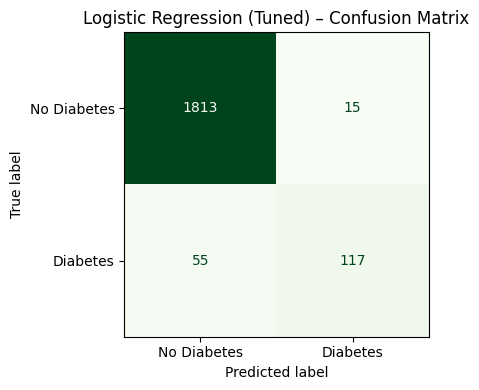


=== LR Results Summary ===


,Model,Accuracy,Precision,Recall,F1
0,LR split 60/40,0.9610,0.8672,0.6453,0.7400
1,LR split 70/30,0.9627,0.8614,0.6744,0.7565
2,LR split 80/20,0.9650,0.8864,0.6802,0.7697
3,LR seed=0,0.9625,0.9008,0.6337,0.7440
4,LR seed=42,0.9650,0.8864,0.6802,0.7697
5,LR seed=123,0.9615,0.8800,0.6395,0.7407
6,LR (no tuning),0.9650,0.8864,0.6802,0.7697
7,LR (tuned),0.9650,0.8864,0.6802,0.7697


In [5]:
from sklearn.linear_model import LogisticRegression

lr_results = []

# ---- Different split ratios ----
print("=== LR: Effect of Train-Test Split Ratio ===")
for test_size in [0.40, 0.30, 0.20]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
    pipe.fit(X_tr, y_tr)
    m = get_metrics(y_te, pipe.predict(X_te), f'LR split {int((1-test_size)*100)}/{int(test_size*100)}')
    lr_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- Different random seeds ----
print("\n=== LR: Effect of Random Seed ===")
for seed in [0, 42, 123]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=seed, stratify=y)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=seed))
    pipe.fit(X_tr, y_tr)
    m = get_metrics(y_te, pipe.predict(X_te), f'LR seed={seed}')
    lr_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- K-Fold CV ----
print("\n=== LR: K-Fold CV (k=3,5,10) ===")
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
for k in [3, 5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(pipe_lr, X, y, cv=skf, scoring='f1')
    print(f"  k={k}: mean F1={scores.mean():.4f}  std={scores.std():.4f}")

# ---- Without vs With Tuning ----
print("\n=== LR: Without vs With Hyperparameter Tuning ===")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

pipe_lr_base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
pipe_lr_base.fit(X_tr, y_tr)
m_lr_base = get_metrics(y_te, pipe_lr_base.predict(X_te), 'LR (no tuning)')
lr_results.append(m_lr_base)
print(f"  {m_lr_base['Model']}: Acc={m_lr_base['Accuracy']:.4f}  F1={m_lr_base['F1']:.4f}")

param_grid_lr = {'logisticregression__C': [0.01, 0.1, 1, 10, 100],
                 'logisticregression__solver': ['lbfgs', 'liblinear']}
gs_lr = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                     param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
gs_lr.fit(X_tr, y_tr)
m_lr_tuned = get_metrics(y_te, gs_lr.predict(X_te), 'LR (tuned)')
lr_results.append(m_lr_tuned)
print(f"  {m_lr_tuned['Model']}: Acc={m_lr_tuned['Accuracy']:.4f}  F1={m_lr_tuned['F1']:.4f}")
print(f"  Best params: {gs_lr.best_params_}")

# Confusion matrix
cm_lr = confusion_matrix(y_te, gs_lr.predict(X_te))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(5,4))
disp_lr.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Logistic Regression (Tuned) – Confusion Matrix')
plt.tight_layout()
plt.show()

print("\n=== LR Results Summary ===")
display(pd.DataFrame(lr_results).round(4))

### 4.3 Decision Tree – Systematic Experiments

=== Decision Tree: Split Ratios ===
  DT split 60/40: Acc=0.9523  F1=0.7236
  DT split 70/30: Acc=0.9550  F1=0.7429
  DT split 80/20: Acc=0.9500  F1=0.7175

=== Decision Tree: Random Seeds ===
  DT seed=0: Acc=0.9560  F1=0.7500
  DT seed=42: Acc=0.9500  F1=0.7175
  DT seed=123: Acc=0.9545  F1=0.7422

=== Decision Tree: K-Fold CV ===
  k=3: mean F1=0.7182  std=0.0210
  k=5: mean F1=0.7248  std=0.0314
  k=10: mean F1=0.7290  std=0.0307

=== Decision Tree: Without vs With Hyperparameter Tuning ===
  DT (no tuning): Acc=0.9500  F1=0.7175
  DT (tuned): Acc=0.9720  F1=0.8056
  Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


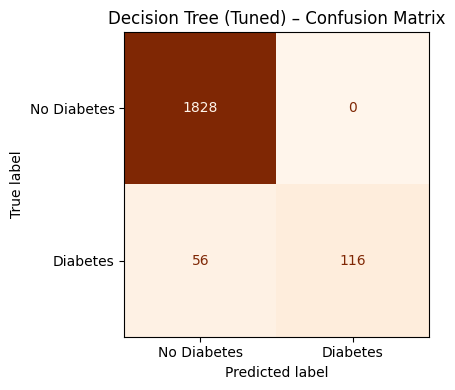


=== DT Results Summary ===


,Model,Accuracy,Precision,Recall,F1
0,DT split 60/40,0.9522,0.7205,0.7267,0.7236
1,DT split 70/30,0.9550,0.7303,0.7558,0.7429
2,DT split 80/20,0.9500,0.6978,0.7384,0.7175
3,DT seed=0,0.9560,0.7333,0.7674,0.7500
4,DT seed=42,0.9500,0.6978,0.7384,0.7175
5,DT seed=123,0.9545,0.7238,0.7616,0.7422
6,DT (no tuning),0.9500,0.6978,0.7384,0.7175
7,DT (tuned),0.9720,1.0000,0.6744,0.8056


In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_results = []

# ---- Split ratios ----
print("=== Decision Tree: Split Ratios ===")
for test_size in [0.40, 0.30, 0.20]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_tr, y_tr)
    m = get_metrics(y_te, dt.predict(X_te), f'DT split {int((1-test_size)*100)}/{int(test_size*100)}')
    dt_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- Random seeds ----
print("\n=== Decision Tree: Random Seeds ===")
for seed in [0, 42, 123]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=seed, stratify=y)
    dt = DecisionTreeClassifier(random_state=seed)
    dt.fit(X_tr, y_tr)
    m = get_metrics(y_te, dt.predict(X_te), f'DT seed={seed}')
    dt_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- K-Fold CV ----
print("\n=== Decision Tree: K-Fold CV ===")
for k in [3, 5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=skf, scoring='f1')
    print(f"  k={k}: mean F1={scores.mean():.4f}  std={scores.std():.4f}")

# ---- Without vs With Tuning ----
print("\n=== Decision Tree: Without vs With Hyperparameter Tuning ===")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_tr, y_tr)
m_dt_base = get_metrics(y_te, dt_base.predict(X_te), 'DT (no tuning)')
dt_results.append(m_dt_base)
print(f"  {m_dt_base['Model']}: Acc={m_dt_base['Accuracy']:.4f}  F1={m_dt_base['F1']:.4f}")

param_grid_dt = {'max_depth': [3, 5, 10, None],
                 'min_samples_split': [2, 5, 10],
                 'criterion': ['gini', 'entropy']}
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
gs_dt.fit(X_tr, y_tr)
m_dt_tuned = get_metrics(y_te, gs_dt.predict(X_te), 'DT (tuned)')
dt_results.append(m_dt_tuned)
print(f"  {m_dt_tuned['Model']}: Acc={m_dt_tuned['Accuracy']:.4f}  F1={m_dt_tuned['F1']:.4f}")
print(f"  Best params: {gs_dt.best_params_}")

# Confusion matrix
cm_dt = confusion_matrix(y_te, gs_dt.predict(X_te))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(5,4))
disp_dt.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Decision Tree (Tuned) – Confusion Matrix')
plt.tight_layout()
plt.show()

print("\n=== DT Results Summary ===")
display(pd.DataFrame(dt_results).round(4))

### 4.4 Random Forest – Systematic Experiments

=== Random Forest: Split Ratios ===
  RF split 60/40: Acc=0.9710  F1=0.8007
  RF split 70/30: Acc=0.9703  F1=0.7973
  RF split 80/20: Acc=0.9705  F1=0.7986

=== Random Forest: Random Seeds ===
  RF seed=0: Acc=0.9735  F1=0.8203
  RF seed=42: Acc=0.9705  F1=0.7986
  RF seed=123: Acc=0.9725  F1=0.8148

=== Random Forest: K-Fold CV ===
  k=3: mean F1=0.8069  std=0.0294
  k=5: mean F1=0.8004  std=0.0324
  k=10: mean F1=0.8049  std=0.0430

=== Random Forest: Without vs With Hyperparameter Tuning ===
  RF (no tuning): Acc=0.9705  F1=0.7986
  RF (tuned): Acc=0.9710  F1=0.8027
  Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 20}


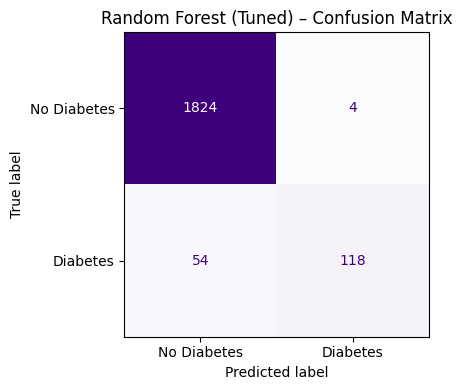

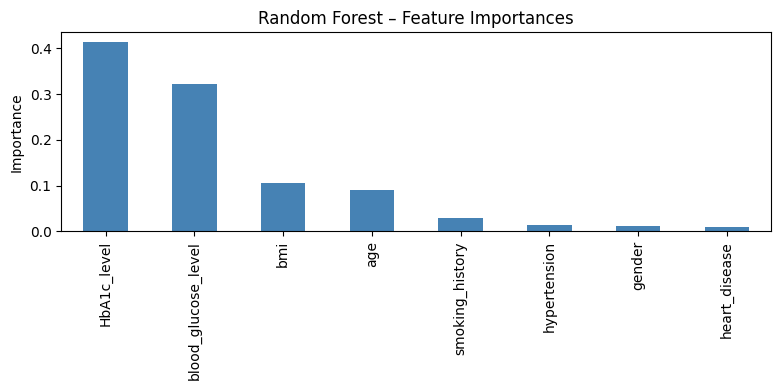


=== RF Results Summary ===


,Model,Accuracy,Precision,Recall,F1
0,RF split 60/40,0.9710,0.9790,0.6773,0.8007
1,RF split 70/30,0.9703,0.9669,0.6783,0.7973
2,RF split 80/20,0.9705,0.9669,0.6802,0.7986
3,RF seed=0,0.9735,0.9837,0.7035,0.8203
4,RF seed=42,0.9705,0.9669,0.6802,0.7986
5,RF seed=123,0.9725,0.9680,0.7035,0.8148
6,RF (no tuning),0.9705,0.9669,0.6802,0.7986
7,RF (tuned),0.9710,0.9672,0.6860,0.8027


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_results = []

# ---- Split ratios ----
print("=== Random Forest: Split Ratios ===")
for test_size in [0.40, 0.30, 0.20]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    m = get_metrics(y_te, rf.predict(X_te), f'RF split {int((1-test_size)*100)}/{int(test_size*100)}')
    rf_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- Random seeds ----
print("\n=== Random Forest: Random Seeds ===")
for seed in [0, 42, 123]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=seed, stratify=y)
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)
    rf.fit(X_tr, y_tr)
    m = get_metrics(y_te, rf.predict(X_te), f'RF seed={seed}')
    rf_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- K-Fold CV ----
print("\n=== Random Forest: K-Fold CV ===")
for k in [3, 5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                             X, y, cv=skf, scoring='f1')
    print(f"  k={k}: mean F1={scores.mean():.4f}  std={scores.std():.4f}")

# ---- Without vs With Tuning ----
print("\n=== Random Forest: Without vs With Hyperparameter Tuning ===")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_tr, y_tr)
m_rf_base = get_metrics(y_te, rf_base.predict(X_te), 'RF (no tuning)')
rf_results.append(m_rf_base)
print(f"  {m_rf_base['Model']}: Acc={m_rf_base['Accuracy']:.4f}  F1={m_rf_base['F1']:.4f}")

from sklearn.model_selection import RandomizedSearchCV
param_dist_rf = {'n_estimators': [50, 100, 200],
                 'max_depth': [5, 10, 20, None],
                 'min_samples_split': [2, 5, 10],
                 'max_features': ['sqrt', 'log2']}
rs_rf = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                           param_dist_rf, n_iter=15, cv=5, scoring='f1',
                           random_state=42, n_jobs=-1)
rs_rf.fit(X_tr, y_tr)
m_rf_tuned = get_metrics(y_te, rs_rf.predict(X_te), 'RF (tuned)')
rf_results.append(m_rf_tuned)
print(f"  {m_rf_tuned['Model']}: Acc={m_rf_tuned['Accuracy']:.4f}  F1={m_rf_tuned['F1']:.4f}")
print(f"  Best params: {rs_rf.best_params_}")

# Confusion matrix
cm_rf = confusion_matrix(y_te, rs_rf.predict(X_te))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(5,4))
disp_rf.plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Random Forest (Tuned) – Confusion Matrix')
plt.tight_layout()
plt.show()

# Feature importance
importances = rs_rf.best_estimator_.feature_importances_
feat_df = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
feat_df.plot(kind='bar', color='steelblue')
plt.title('Random Forest – Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print("\n=== RF Results Summary ===")
display(pd.DataFrame(rf_results).round(4))

## 5. Unsupervised Model – K-Means Clustering

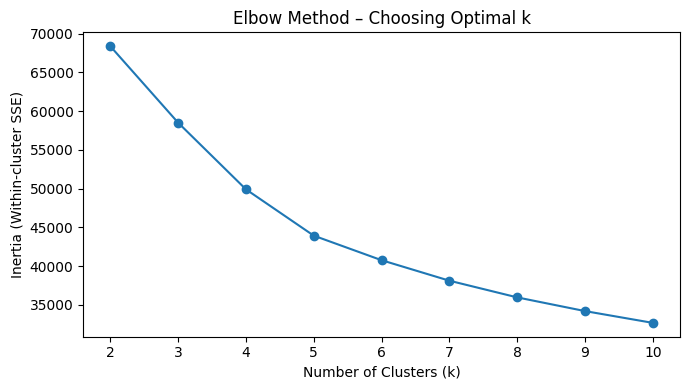

=== K-Means: k=2,3,4 with Silhouette, ARI, AMI ===
  k=2: Silhouette=0.1473  ARI=0.0371  AMI=0.1017
  k=3: Silhouette=0.1551  ARI=0.0261  AMI=0.0794
  k=4: Silhouette=0.1821  ARI=0.0358  AMI=0.0637

=== K-Means Results Table ===


,k,Silhouette,ARI,AMI
0,2,0.1473,0.0371,0.1017
1,3,0.1551,0.0261,0.0794
2,4,0.1821,0.0358,0.0637


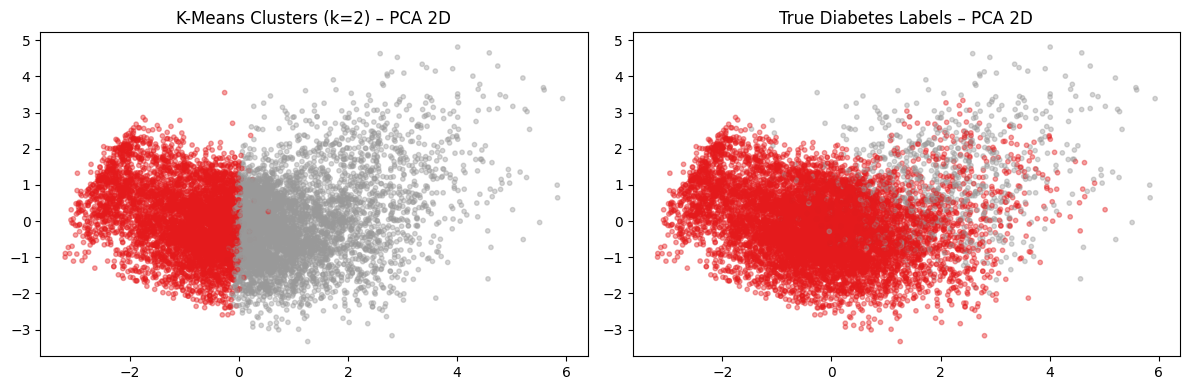

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              adjusted_mutual_info_score)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- Elbow method to choose k ----
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.title('Elbow Method – Choosing Optimal k')
plt.tight_layout()
plt.show()

# ---- Evaluate k = 2, 3, 4 with three metrics ----
print("=== K-Means: k=2,3,4 with Silhouette, ARI, AMI ===")
kmeans_summary = []
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil  = silhouette_score(X_scaled, labels)
    ari  = adjusted_rand_score(y, labels)
    ami  = adjusted_mutual_info_score(y, labels)
    kmeans_summary.append({'k': k, 'Silhouette': sil, 'ARI': ari, 'AMI': ami})
    print(f"  k={k}: Silhouette={sil:.4f}  ARI={ari:.4f}  AMI={ami:.4f}")

print("\n=== K-Means Results Table ===")
display(pd.DataFrame(kmeans_summary).round(4))

# ---- Cluster visualisation (PCA 2D) ----
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

km_best = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
labels_best = km_best.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_best, cmap='Set1', alpha=0.4, s=10)
axes[0].set_title('K-Means Clusters (k=2) – PCA 2D')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='Set1', alpha=0.4, s=10)
axes[1].set_title('True Diabetes Labels – PCA 2D')
plt.tight_layout()
plt.show()

## 6. Ensemble Models

=== Base Models (80/20 split, no tuning) ===
  Base SVM: Acc=0.9635  F1=0.7384
  Base LR: Acc=0.9650  F1=0.7697
  Base DT: Acc=0.9500  F1=0.7175
  Base RF: Acc=0.9705  F1=0.7986

=== Bagging Classifier ===
  Bagging (DT base): Acc=0.9700  F1=0.8000

=== Boosting Classifiers ===
  AdaBoost: Acc=0.9700  F1=0.7887
  Gradient Boosting: Acc=0.9705  F1=0.8000

=== Voting Classifiers ===
  Voting (Hard): Acc=0.9720  F1=0.8069
  Voting (Soft): Acc=0.9715  F1=0.8028

=== Stacking Classifiers ===
  Stacking A (LR+RF→DT): Acc=0.9720  F1=0.8056
  Stacking B (DT+RF→LR): Acc=0.9720  F1=0.8069

=== Ensemble vs Base Models – Full Comparison ===


,Model,Accuracy,Precision,Recall,F1
10,Stacking B (DT+RF→LR),0.9720,0.9915,0.6802,0.8069
7,Voting (Hard),0.9720,0.9915,0.6802,0.8069
9,Stacking A (LR+RF→DT),0.9720,1.0000,0.6744,0.8056
8,Voting (Soft),0.9715,0.9915,0.6744,0.8028
6,Gradient Boosting,0.9705,0.9593,0.6860,0.8000
4,Bagging (DT base),0.9700,0.9375,0.6977,0.8000
3,Base RF,0.9705,0.9669,0.6802,0.7986
5,AdaBoost,0.9700,1.0000,0.6512,0.7887
1,Base LR,0.9650,0.8864,0.6802,0.7697
0,Base SVM,0.9635,0.9626,0.5988,0.7384


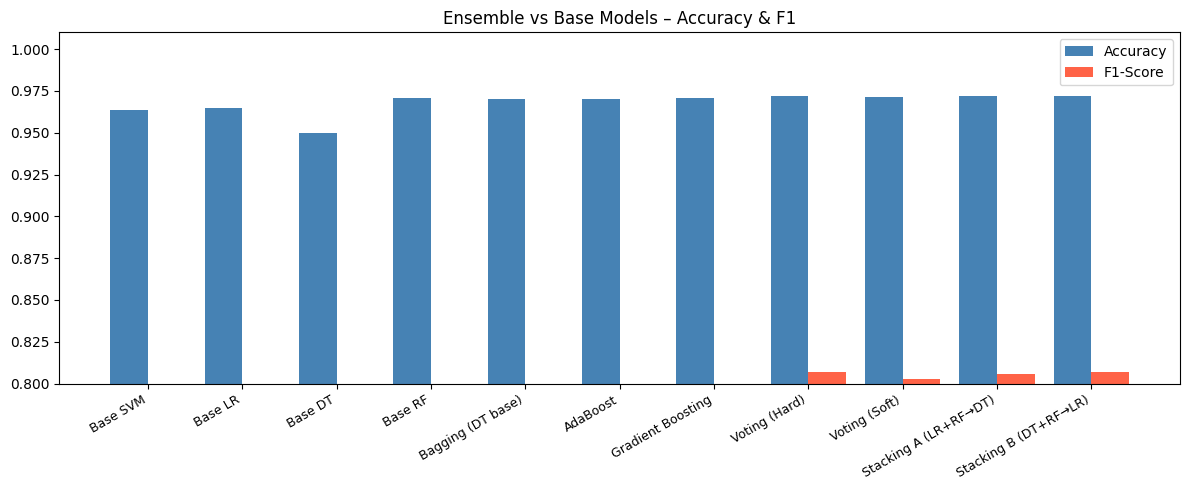

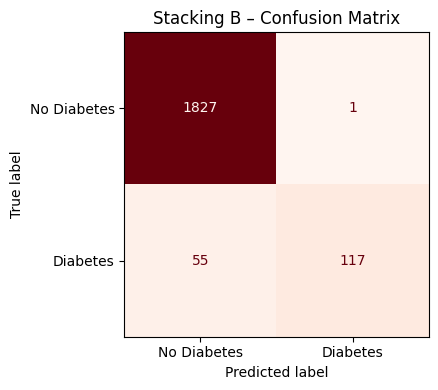

In [9]:
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, VotingClassifier,
                               StackingClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

ensemble_results = []

# ---- Base models (for comparison) ----
print("=== Base Models (80/20 split, no tuning) ===")
base_models = [
    ('SVM',  make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))),
    ('LR',   make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))),
    ('DT',   DecisionTreeClassifier(random_state=42)),
    ('RF',   RandomForestClassifier(n_estimators=100, random_state=42)),
]
for name, model in base_models:
    model.fit(X_tr, y_tr)
    m = get_metrics(y_te, model.predict(X_te), f'Base {name}')
    ensemble_results.append(m)
    print(f"  {m['Model']}: Acc={m['Accuracy']:.4f}  F1={m['F1']:.4f}")

# ---- 6.1 Bagging ----
print("\n=== Bagging Classifier ===")
bag = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                        n_estimators=100, random_state=42)
bag.fit(X_tr, y_tr)
m_bag = get_metrics(y_te, bag.predict(X_te), 'Bagging (DT base)')
ensemble_results.append(m_bag)
print(f"  {m_bag['Model']}: Acc={m_bag['Accuracy']:.4f}  F1={m_bag['F1']:.4f}")

# ---- 6.2 Boosting ----
print("\n=== Boosting Classifiers ===")
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_tr, y_tr)
m_ada = get_metrics(y_te, ada.predict(X_te), 'AdaBoost')
ensemble_results.append(m_ada)
print(f"  {m_ada['Model']}: Acc={m_ada['Accuracy']:.4f}  F1={m_ada['F1']:.4f}")

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_tr, y_tr)
m_gb = get_metrics(y_te, gb.predict(X_te), 'Gradient Boosting')
ensemble_results.append(m_gb)
print(f"  {m_gb['Model']}: Acc={m_gb['Accuracy']:.4f}  F1={m_gb['F1']:.4f}")

# ---- 6.3 Voting Classifier ----
print("\n=== Voting Classifiers ===")
estimators_vote = [
    ('lr',  make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
]
vote_hard = VotingClassifier(estimators=estimators_vote, voting='hard')
vote_hard.fit(X_tr, y_tr)
m_vh = get_metrics(y_te, vote_hard.predict(X_te), 'Voting (Hard)')
ensemble_results.append(m_vh)
print(f"  {m_vh['Model']}: Acc={m_vh['Accuracy']:.4f}  F1={m_vh['F1']:.4f}")

vote_soft = VotingClassifier(estimators=estimators_vote, voting='soft')
vote_soft.fit(X_tr, y_tr)
m_vs = get_metrics(y_te, vote_soft.predict(X_te), 'Voting (Soft)')
ensemble_results.append(m_vs)
print(f"  {m_vs['Model']}: Acc={m_vs['Accuracy']:.4f}  F1={m_vs['F1']:.4f}")

# ---- 6.4 Stacking ----
print("\n=== Stacking Classifiers ===")
base_A = [
    ('lr', make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]
stack_A = StackingClassifier(estimators=base_A,
                              final_estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
                              cv=5)
stack_A.fit(X_tr, y_tr)
m_sA = get_metrics(y_te, stack_A.predict(X_te), 'Stacking A (LR+RF→DT)')
ensemble_results.append(m_sA)
print(f"  {m_sA['Model']}: Acc={m_sA['Accuracy']:.4f}  F1={m_sA['F1']:.4f}")

base_B = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]
stack_B = StackingClassifier(estimators=base_B,
                              final_estimator=make_pipeline(StandardScaler(),
                                                            LogisticRegression(max_iter=1000)),
                              cv=5)
stack_B.fit(X_tr, y_tr)
m_sB = get_metrics(y_te, stack_B.predict(X_te), 'Stacking B (DT+RF→LR)')
ensemble_results.append(m_sB)
print(f"  {m_sB['Model']}: Acc={m_sB['Accuracy']:.4f}  F1={m_sB['F1']:.4f}")

# ---- Summary table + bar chart ----
ens_df = pd.DataFrame(ensemble_results).round(4)
print("\n=== Ensemble vs Base Models – Full Comparison ===")
display(ens_df.sort_values('F1', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(ens_df))
ax.bar([i - 0.2 for i in x], ens_df['Accuracy'], width=0.4, label='Accuracy', color='steelblue')
ax.bar([i + 0.2 for i in x], ens_df['F1'],       width=0.4, label='F1-Score',  color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(ens_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0.8, 1.01)
ax.set_title('Ensemble vs Base Models – Accuracy & F1')
ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrices for best ensemble
best_ens = stack_B  # update if a different model wins
cm_ens = confusion_matrix(y_te, best_ens.predict(X_te))
disp_ens = ConfusionMatrixDisplay(confusion_matrix=cm_ens, display_labels=['No Diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(5,4))
disp_ens.plot(ax=ax, colorbar=False, cmap='Reds')
ax.set_title('Stacking B – Confusion Matrix')
plt.tight_layout()
plt.show()

## 7. Overall Model Comparison Summary

=== All Models – Final Performance Summary ===


,Model,Accuracy,Precision,Recall,F1
0,Stacking B,0.9720,0.9915,0.6802,0.8069
1,Voting Hard,0.9720,0.9915,0.6802,0.8069
2,Decision Tree (tuned),0.9720,1.0000,0.6744,0.8056
3,Stacking A,0.9720,1.0000,0.6744,0.8056
4,Voting Soft,0.9715,0.9915,0.6744,0.8028
5,Random Forest (tuned),0.9710,0.9672,0.6860,0.8027
6,Bagging,0.9700,0.9375,0.6977,0.8000
7,Gradient Boost,0.9705,0.9593,0.6860,0.8000
8,AdaBoost,0.9700,1.0000,0.6512,0.7887
9,SVM (tuned),0.9665,0.9412,0.6512,0.7698


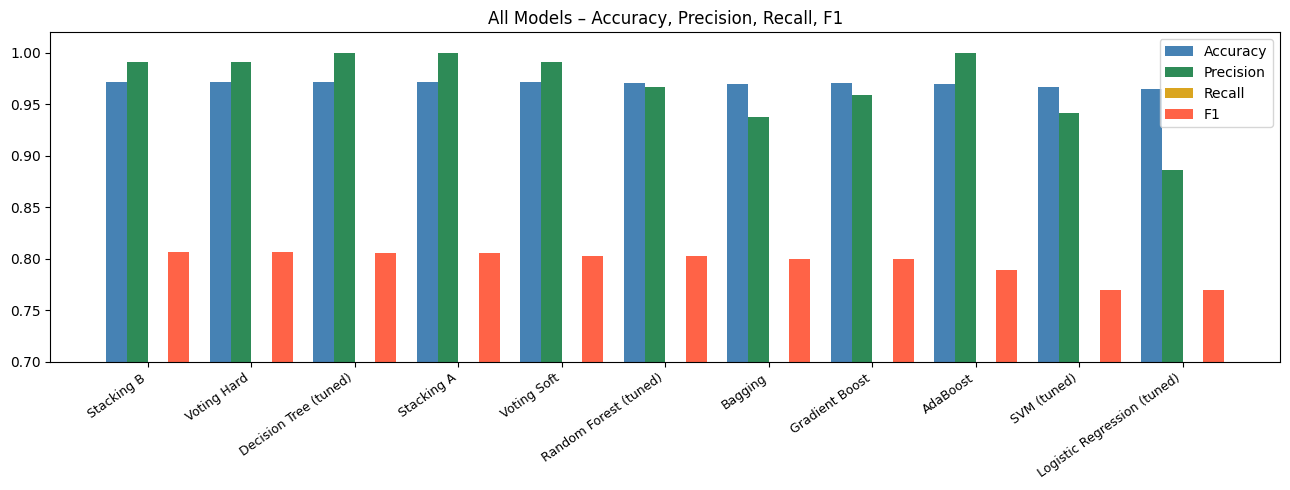

In [10]:
# Collect one representative result per model family (80/20, no tuning)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

summary_models = [
    ('SVM (tuned)',        gs),
    ('Logistic Regression (tuned)', gs_lr),
    ('Decision Tree (tuned)',       gs_dt),
    ('Random Forest (tuned)',       rs_rf),
]

ensemble_named = [
    ('Bagging',         bag),
    ('AdaBoost',        ada),
    ('Gradient Boost',  gb),
    ('Voting Hard',     vote_hard),
    ('Voting Soft',     vote_soft),
    ('Stacking A',      stack_A),
    ('Stacking B',      stack_B),
]

all_summary = []
for name, model in summary_models + ensemble_named:
    m = get_metrics(y_te, model.predict(X_te), name)
    all_summary.append(m)

summary_df = pd.DataFrame(all_summary).sort_values('F1', ascending=False).reset_index(drop=True)
print("=== All Models – Final Performance Summary ===")
display(summary_df.round(4))

# Visual summary
fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(summary_df))
ax.bar([i-0.3 for i in x], summary_df['Accuracy'],  width=0.2, label='Accuracy',  color='steelblue')
ax.bar([i-0.1 for i in x], summary_df['Precision'], width=0.2, label='Precision', color='seagreen')
ax.bar([i+0.1 for i in x], summary_df['Recall'],    width=0.2, label='Recall',    color='goldenrod')
ax.bar([i+0.3 for i in x], summary_df['F1'],        width=0.2, label='F1',        color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(summary_df['Model'], rotation=35, ha='right', fontsize=9)
ax.set_ylim(0.7, 1.02)
ax.set_title('All Models – Accuracy, Precision, Recall, F1')
ax.legend()
plt.tight_layout()
plt.show()